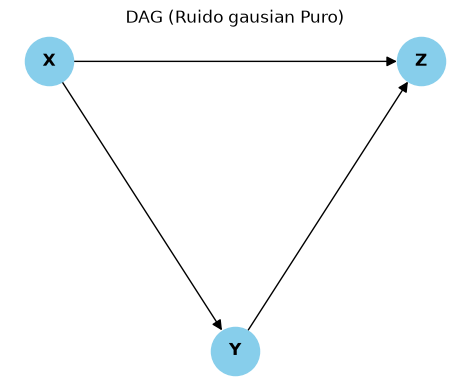

No hay CSV previo: se entrena la rejilla completa desde cero.

######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 50
 -> Entrenando MSE para N=50 y semilla=42...
Using device: cpu
Early stopping at step 340
Using device: cpu
Early stopping at step 277
 -> Entrenando HSIC para N=50 y semilla=42...
Using device: cpu
Early stopping at step 292
Using device: cpu
Early stopping at step 87
 -> Entrenando HYBRID_ALPHA0.1 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 286
Using device: cpu
Early stopping at step 124
 -> Entrenando HYBRID_ALPHA0.2 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 251
Using device: cpu
Early stopping at step 91
 -> Entrenando HYBRID_ALPHA0.3 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 262
Using device: cpu
Early stopping at step 92
 -> Entre

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,50,0.89869,0.84620,0.10600,1.48414,0.80192,0.20372,0.03459,0.00292,0.08784,0.625
12,1,42,hsic,HSIC,0.0,1.0,100,1.08283,0.93811,0.13429,1.42429,0.73621,0.06860,0.03358,0.00287,0.14247,0.750
23,1,42,hsic,HSIC,0.0,1.0,300,0.55366,0.60058,0.10770,1.18246,0.71939,0.04596,0.03379,0.00293,0.16223,0.750
34,1,42,hsic,HSIC,0.0,1.0,500,0.50752,0.58574,0.06692,1.80317,1.07082,0.04591,0.02058,0.00239,0.21212,0.775
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,50,0.29607,0.35702,0.14610,1.12283,0.85819,0.03459,0.02030,0.00197,0.05263,0.675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,20,61,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,0.25919,0.33721,0.19984,0.81226,0.66321,0.17441,0.08076,0.00160,0.02941,0.750
836,20,61,mse,MSE,1.0,0.0,50,0.33833,0.38245,0.21748,0.82488,0.67480,0.17916,0.06986,0.00141,0.03404,0.750
847,20,61,mse,MSE,1.0,0.0,100,0.25038,0.35467,0.22037,1.32319,0.79900,0.32862,0.05736,0.00324,0.04749,0.725
858,20,61,mse,MSE,1.0,0.0,300,0.22715,0.32636,0.24211,0.89023,0.69365,0.25680,0.06927,0.00178,0.03444,0.650


Tabla maestra guardada en: tablas/multiplicativo_exponencial.csv


In [7]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gamma centrado (media 0, varianza escala**2)."""
    np.random.seed(seed)
    eps_X = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Y = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Z = np.random.exponential(scale=escala, size=num_samples) - escala
    
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X)* eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) * eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar.
# IMPORTANTE: a partir de ahora N_actual es directamente el número de muestras de
# ENTRENAMIENTO (ya no se genera 2*N y se parte a la mitad).
valores_N_experimento = [50,100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
# 20 semillas: las 10 originales (42-51, incluyen los outliers ya observados con
# KAN α=0.3) + 10 nuevas (52-61), para ganar precisión sin descartar ninguna
# observación real (descartar las semillas con outliers sesgaría la varianza).
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                                  52, 53, 54, 55, 56, 57, 58, 59, 60, 61])

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# --- CONJUNTO DE EVALUACIÓN FIJO ---
# Para que todos los experimentos (distinto N, distinta semilla, y también el Causal
# Flow del Paso 8) sean totalmente comparables entre sí, evaluamos SIEMPRE contra las
# mismas 100 muestras, generadas una única vez aquí con una semilla propia (fuera de
# `semillas_experimento`, para que nunca coincida con ningún conjunto de entrenamiento).
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999
factual_eval_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO, escala=1.0)
datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
num_muestras_eval = len(factual_eval_d)

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido gausian Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

# --- [PASO 2b: REANUDACION - no se reentrena nada que ya este en el CSV] ---
# Los KANs no se guardan en disco: lo que se conserva son las filas de metricas ya
# calculadas. Al releerlas, cualquier combinacion (Seed, N, Alpha, Beta) que ya exista se
# omite, de modo que relanzar el notebook (o ampliar la rejilla de alphas/N/semillas) solo
# entrena lo que falta.
def clave_run(seed, n, alpha, beta):
    """Identificador de un run. Sirve para no reentrenar lo que ya esta en el CSV."""
    return (int(seed), int(n), round(float(alpha), 5), round(float(beta), 5))

carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo = os.path.join(carpeta_tablas, "multiplicativo_exponencial.csv")

if os.path.exists(ruta_archivo):
    df_previo = pd.read_csv(ruta_archivo)
    runs_hechos = {clave_run(r.Seed, r.N, r.Alpha, r.Beta) for r in df_previo.itertuples(index=False)}
    print(f"Reanudando desde {ruta_archivo}: {len(df_previo)} runs ya calculados -> no se reentrenan.")
else:
    df_previo = pd.DataFrame()
    runs_hechos = set()
    print("No hay CSV previo: se entrena la rejilla completa desde cero.")

registros_tabla_final = []


def guardar_checkpoint():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_tabla_final:
        return
    df_ckpt = pd.concat([df_previo, pd.DataFrame(registros_tabla_final)], ignore_index=True)
    df_ckpt.to_csv(ruta_archivo, index=False)


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación del conjunto de ENTRENAMIENTO con exactamente N_actual muestras.
        #    El conjunto de EVALUACIÓN es fijo (factual_eval_d / datos_reales_test /
        #    num_muestras_eval), generado una única vez en el Paso 2, y es el mismo
        #    para todas las semillas y todos los N -> resultados comparables entre sí.
        factual_train_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)

            # Ya calculado en una ejecucion anterior: se conserva su fila del CSV y no se reentrena.
            if clave_run(seed, N_actual, alpha_val, beta_val) in runs_hechos:
                continue

            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico sobre el conjunto de evaluación FIJO (factual_eval_d)
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

    # Checkpoint tras cada semilla: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint()

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_nuevos = pd.DataFrame(registros_tabla_final)
df_final_multi_n = pd.concat([df_previo, df_nuevos], ignore_index=True) if len(df_previo) else df_nuevos
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print(f"\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA --- "
      f"{len(df_final_multi_n)} runs en total | {len(df_nuevos)} entrenados ahora | {len(df_previo)} reutilizados")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
# carpeta_tablas / ruta_archivo ya se definieron en el PASO 2b (reanudacion)
df_final_multi_n.to_csv(ruta_archivo, index=False)
print(f"Tabla maestra guardada en: {ruta_archivo}")

In [8]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # # Guardar cada tabla N en un CSV separado
    # ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_multiplicativo_exponencial.csv")
    # if not os.path.exists("tablas"):
    #     os.makedirs("tablas")
    # df_resumen_n.to_csv(ruta_resumen_n, index=False)
    # print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 50 MUESTRAS
####################################################################################################

Tabla resumen para N=50:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,20,0.35490,0.08591,0.39079,0.04153,0.21898,...,0.21818,0.10347,0.05991,0.02267,0.00267,0.00140,0.07641,0.07180,0.73875,0.05470
0,0.0,1.0,hsic,HSIC,20,0.76100,0.30175,0.67050,0.22257,0.22578,...,0.11288,0.08304,0.05162,0.04351,0.00407,0.00181,0.20704,0.13335,0.78250,0.10733
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,0.36131,0.08779,0.39183,0.04206,0.21648,...,0.15962,0.08937,0.05949,0.03166,0.00193,0.00094,0.06116,0.04008,0.71375,0.04899
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,0.36228,0.08955,0.39117,0.04251,0.21612,...,0.15584,0.08049,0.05964,0.03063,0.00194,0.00101,0.06177,0.04198,0.71875,0.04992
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,0.36919,0.09519,0.39288,0.04714,0.21391,...,0.14816,0.08648,0.05700,0.03851,0.00197,0.00103,0.06497,0.04557,0.72500,0.06070
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,0.37661,0.09949,0.39763,0.05185,0.21362,...,0.14968,0.08820,0.05676,0.04033,0.00193,0.00107,0.06465,0.04704,0.72250,0.05495
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,0.37310,0.10553,0.39828,0.05335,0.21608,...,0.14702,0.09203,0.05349,0.04054,0.00209,0.00103,0.06507,0.04465,0.71625,0.05808
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,0.37330,0.10739,0.39806,0.05339,0.21504,...,0.14031,0.09586,0.04743,0.03365,0.00203,0.00106,0.06517,0.04592,0.72750,0.06064
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,0.36351,0.09870,0.39345,0.05212,0.21355,...,0.14260,0.09722,0.04842,0.03144,0.00200,0.00104,0.06681,0.04670,0.72875,0.06245
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,0.38096,0.10496,0.40391,0.05638,0.22397,...,0.12639,0.09106,0.04529,0.03103,0.00196,0.00105,0.06921,0.05083,0.72125,0.06702




####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,20,0.32237,0.08981,0.38278,0.03569,0.23791,...,0.21211,0.10161,0.06474,0.01973,0.00226,0.00126,0.06658,0.04999,0.73125,0.04045
0,0.0,1.0,hsic,HSIC,20,0.77783,0.28110,0.70385,0.20131,0.19925,...,0.09135,0.06874,0.06277,0.04239,0.00381,0.00144,0.23914,0.11676,0.80750,0.07394
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,0.31755,0.09250,0.37387,0.03954,0.22255,...,0.16702,0.09666,0.06090,0.02441,0.00181,0.00115,0.05448,0.02689,0.71375,0.03579
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,0.31848,0.09172,0.37096,0.04162,0.21501,...,0.16950,0.09302,0.06019,0.02231,0.00175,0.00112,0.05945,0.04289,0.72250,0.05374
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,0.30205,0.08772,0.36198,0.04061,0.20314,...,0.14416,0.09049,0.05262,0.02161,0.00158,0.00106,0.05394,0.02497,0.72500,0.03717
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,0.30643,0.09374,0.36253,0.04370,0.20045,...,0.12641,0.09266,0.04612,0.02388,0.00153,0.00105,0.05907,0.03414,0.71875,0.04433
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,0.30258,0.09272,0.36067,0.04346,0.19430,...,0.11636,0.08614,0.04249,0.02358,0.00150,0.00103,0.05757,0.03217,0.72125,0.03371
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,0.31551,0.09636,0.37253,0.04647,0.19151,...,0.11476,0.08269,0.04295,0.02373,0.00164,0.00098,0.05998,0.03423,0.70750,0.04523
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,0.32417,0.09342,0.38280,0.04544,0.18695,...,0.11392,0.07979,0.04348,0.02456,0.00175,0.00100,0.06036,0.03256,0.70750,0.04667
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,0.34047,0.09912,0.39482,0.04944,0.19427,...,0.10238,0.05886,0.04239,0.02683,0.00170,0.00090,0.06307,0.03265,0.72125,0.04885




####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



...

,Media ± Std
MSE Y,0.25362 ± 0.03291
MAE Y,0.32984 ± 0.02209
"HSIC(Y,X)",0.19073 ± 0.02650
MSE Z,0.77479 ± 0.09148
MAE Z,0.64588 ± 0.03420
"HSIC(Z,X)",0.12937 ± 0.07731
"HSIC(Z,Y)",0.05656 ± 0.02666
dHSIC Total,0.00130 ± 0.00037
MMD,0.06959 ± 0.05880
RF Acc,0.72125 ± 0.03467



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,0.25586 ± 0.03238
MAE Y,0.33420 ± 0.02198
"HSIC(Y,X)",0.19979 ± 0.02804
MSE Z,0.78927 ± 0.09371
MAE Z,0.65551 ± 0.03503
"HSIC(Z,X)",0.14999 ± 0.07788
"HSIC(Z,Y)",0.06312 ± 0.02549
dHSIC Total,0.00140 ± 0.00040
MMD,0.06797 ± 0.05629
RF Acc,0.71625 ± 0.03828



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,0.25721 ± 0.03266
MAE Y,0.34263 ± 0.02009
"HSIC(Y,X)",0.21383 ± 0.02818
MSE Z,0.82923 ± 0.09782
MAE Z,0.67669 ± 0.03988
"HSIC(Z,X)",0.20369 ± 0.08735
"HSIC(Z,Y)",0.06860 ± 0.01972
dHSIC Total,0.00156 ± 0.00042
MMD,0.06292 ± 0.04796
RF Acc,0.71125 ± 0.03845



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)
(Beta=1, HSIC puro, en eje derecho: subida garantizada para cada N, sin salirse de rango)



✓ Gráfica consolidada guardada: plots/bandplot_todas_N_aditivo_gausian.png



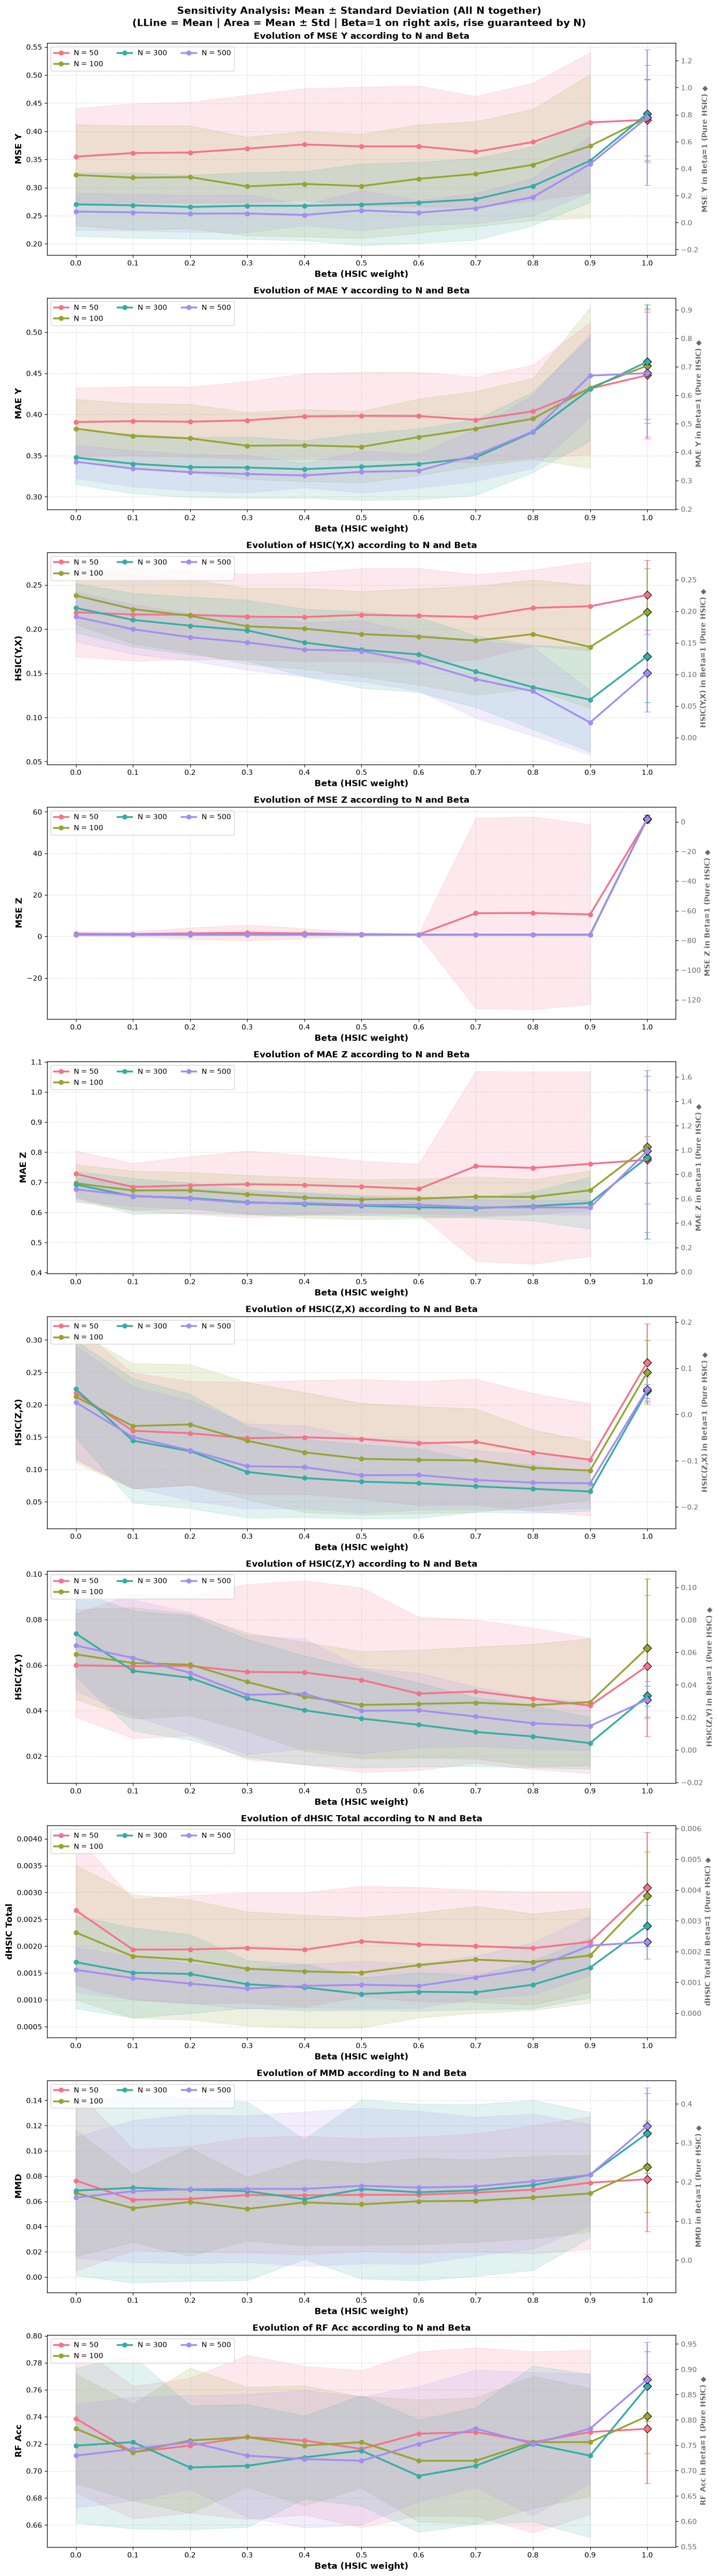

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [9]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# Beta = 1 (HSIC puro) se pinta en un EJE Y SECUNDARIO (derecha) con su propia
# escala, para que su posible subida no comprima/deforme la escala del resto
# de Betas (0 a 0.9, eje izquierdo).
#
# TÉCNICA (v3, definitiva): el ancho del eje derecho se calcula como el MÁXIMO
# de tres necesidades:
#   1) Contención: que quepan todos los puntos de Beta=1 (con su barra de
#      error) de todas las N -> nunca se salen de rango.
#   2) Estética moderada: un mínimo de FACTOR_ANCHO_MAX veces el ancho del eje
#      izquierdo, para que la subida no parezca insignificante.
#   3) Subida garantizada por N: para CADA N cuya subida sea real (Beta=1 >
#      Beta=0.9), se calcula el ancho mínimo necesario para que esa curva en
#      concreto se vea subir en el gráfico (no solo la que domine el rango).
# Se toma el máximo de las tres, así se cumplen las tres a la vez.
#
# Si para alguna N/métrica el valor real de Beta=1 NO es mayor que el de
# Beta=0.9, la línea baja -> eso es honesto, no se fuerza a subir.
#
# Tanto la línea de conexión como la banda de ±std se recortan al área del
# propio subgráfico (`set_clip_path`) para que nunca se salgan del recuadro.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch, Polygon

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("(Beta=1, HSIC puro, en eje derecho: subida garantizada para cada N, sin salirse de rango)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Sensitivity Analysis: Mean ± Standard Deviation (All N together)\n(LLine = Mean | Area = Mean ± Std | Beta=1 on right axis, rise guaranteed by N)', 
             fontsize=14, fontweight='bold', y=0.995)

def _a_coords_figura(fig_obj, ax_obj, punto):
    """Convierte un punto en coordenadas de datos de ax_obj a coordenadas de la figura."""
    disp = ax_obj.transData.transform(punto)
    return fig_obj.transFigure.inverted().transform(disp)

FACTOR_ANCHO_MAX = 1.4   # ancho mínimo "estético" (en veces el ancho del eje izquierdo)
MARGEN_BORDE = 0.05      # margen extra para que ningún punto quede pegado al borde

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    ax2 = ax.twinx()  # Eje secundario: SOLO para el punto Beta = 1 (HSIC puro)

    lineas_leyenda, etiquetas_leyenda = [], []
    puntos_beta1 = []  # (color, x_last, y_last, y_std_last, y1_mean, y1_std)

    # 1ª pasada: pintar Beta<1 en el eje izquierdo y recopilar los puntos de Beta=1
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        color = paleta_n[n_val]

        df_normal = df_n_data[df_n_data['Beta'] < 1.0]
        x = df_normal['Beta'].values
        y_mean = df_normal[f'{metrica}_mean'].values
        y_std = df_normal[f'{metrica}_std'].values

        linea, = ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}',
                          color=color, markersize=6)
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
        lineas_leyenda.append(linea)
        etiquetas_leyenda.append(f'N = {n_val}')

        df_beta1 = df_n_data[df_n_data['Beta'] == 1.0]
        if not df_beta1.empty and len(x) > 0:
            y1_mean = float(df_beta1[f'{metrica}_mean'].values[0])
            y1_std = float(df_beta1[f'{metrica}_std'].values[0])
            puntos_beta1.append((color, x[-1], y_mean[-1], y_std[-1], y1_mean, y1_std))

    # 2ª pasada: calcular el rango del eje derecho como el MÁXIMO de las tres
    # necesidades (contención, estética moderada, subida garantizada por N).
    bottom_ax, top_ax = ax.get_ylim()
    rango_ax = (top_ax - bottom_ax) if top_ax > bottom_ax else 1.0

    if puntos_beta1:
        techo_deseado = max(y1_mean + y1_std for _, _, _, _, y1_mean, y1_std in puntos_beta1)
        suelo_deseado = min(y1_mean - y1_std for _, _, _, _, y1_mean, y1_std in puntos_beta1)
        margen_abs = MARGEN_BORDE * max(techo_deseado - suelo_deseado, rango_ax)
        top2 = techo_deseado + margen_abs

        # 1) Contención: que quepan todos los puntos con su barra de error
        ancho_containment = (techo_deseado - suelo_deseado) + 2 * margen_abs
        # 2) Estética moderada
        ancho_moderado = FACTOR_ANCHO_MAX * rango_ax

        anchos_necesarios = [ancho_containment, ancho_moderado]

        # 3) Subida garantizada: para cada N con subida real, el ancho mínimo
        #    para que su punto quede visualmente por encima de su último punto
        for _, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
            h_last = (y_last - bottom_ax) / rango_ax
            if y1_mean > y_last and h_last < 0.999:
                cota_bottom = (y1_mean - h_last * top2) / (1 - h_last) - margen_abs
                anchos_necesarios.append(top2 - cota_bottom)

        ancho_final = max(anchos_necesarios)
        bottom2 = top2 - ancho_final
        ax2.set_ylim(bottom2, top2)

    # 3ª pasada: pintar el punto de Beta=1, y conectar tanto la media como la banda
    for color, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
        ax2.errorbar([1.0], [y1_mean], yerr=[y1_std], fmt='D', color=color,
                     markersize=8, markeredgecolor='black', markeredgewidth=0.8,
                     capsize=4, elinewidth=1.5, zorder=3)

        # Línea que conecta la media del último punto (Beta=0.9) con la de Beta=1
        con = ConnectionPatch(xyA=(x_last, y_last), coordsA=ax.transData,
                               xyB=(1.0, y1_mean), coordsB=ax2.transData,
                               color=color, linewidth=2.5, zorder=1)
        con.set_clip_path(ax.patch)  # recortar al área del propio subgráfico
        fig.add_artist(con)

        # Banda de ±std conectada entre el último punto y Beta=1
        p_inf_izq = _a_coords_figura(fig, ax, (x_last, y_last - y_std_last))
        p_inf_der = _a_coords_figura(fig, ax2, (1.0, y1_mean - y1_std))
        p_sup_der = _a_coords_figura(fig, ax2, (1.0, y1_mean + y1_std))
        p_sup_izq = _a_coords_figura(fig, ax, (x_last, y_last + y_std_last))

        banda = Polygon([p_inf_izq, p_inf_der, p_sup_der, p_sup_izq], closed=True,
                         transform=fig.transFigure, facecolor=color, alpha=0.15,
                         edgecolor=None, zorder=0)
        banda.set_clip_path(ax.patch)  # recortar al área del propio subgráfico
        fig.add_artist(banda)

    # Estética eje izquierdo (Beta 0 a 0.9)
    ax.set_xlabel('Beta (HSIC weight)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolution of {metrica} according to N and Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks(sorted(df_global['Beta'].unique()))
    ax.legend(lineas_leyenda, etiquetas_leyenda, loc='upper left', fontsize=10, ncol=3)

    # Estética eje derecho
    ax2.set_ylabel(f'{metrica} in Beta=1 (Pure HSIC) ◆', fontsize=10, fontweight='bold', color='dimgray')
    ax2.tick_params(axis='y', labelcolor='dimgray')

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_aditivo_gausian.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")

In [10]:
# ==============================================================================
# PASO 8: CAUSAL FLOW COMO BASELINE INDEPENDIENTE (MISMOS N Y SEMILLAS QUE EL KAN)
# ------------------------------------------------------------------------------
# Objetivo: el KAN (Pasos 2-7) muestra una desviación típica muy grande entre
# semillas. Para saber si eso es un problema propio de la arquitectura/entrenamiento
# del KAN o algo INTRÍNSECO al problema (N pequeño, ruido gausian, triángulo no
# lineal), entrenamos aquí una red completamente distinta (un normalizing flow
# causal, `causalflow_model`) con exactamente los mismos datos, N y semillas.
#
# El flow modela la densidad conjunta directamente (no tiene ecuaciones
# estructurales por nodo ni residuos explícitos), así que las métricas
# comparables "de tarta completa" son MMD y RF Acc (comparan la distribución
# generada contra los datos reales), que además ya calculábamos igual para el KAN.
#
# Igual que en el Paso 3, N_actual es el tamaño del conjunto de ENTRENAMIENTO, y la
# evaluación se hace contra el mismo conjunto FIJO (factual_eval_d / datos_reales_test
# / num_muestras_eval) definido una única vez en el Paso 2 -> comparación 100% justa
# entre KAN y Flow.
# ==============================================================================
from models import causalflow_model, default_flow_params
from copy import deepcopy

# --- REANUDACION: mismo mecanismo que el bucle KAN, no se reentrena lo que ya este en el CSV ---
def clave_run_flow(seed, n):
    """Identificador de un run del Flow. Sirve para no reentrenar lo que ya esta en el CSV."""
    return (int(seed), int(n))

carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo_flow = os.path.join(carpeta_tablas, "causal_flow_multiplicativo_exponencial.csv")

if os.path.exists(ruta_archivo_flow):
    df_flow_previo = pd.read_csv(ruta_archivo_flow)
    runs_flow_hechos = {clave_run_flow(r.Seed, r.N) for r in df_flow_previo.itertuples(index=False)}
    print(f"Reanudando desde {ruta_archivo_flow}: {len(df_flow_previo)} runs ya calculados -> no se reentrenan.")
else:
    df_flow_previo = pd.DataFrame()
    runs_flow_hechos = set()
    print("No hay CSV previo de Causal Flow: se entrena la rejilla completa desde cero.")

registros_flow = []


def guardar_checkpoint_flow():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_flow:
        return
    df_ckpt = pd.concat([df_flow_previo, pd.DataFrame(registros_flow)], ignore_index=True)
    df_ckpt.to_csv(ruta_archivo_flow, index=False)

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"[CAUSAL FLOW] EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        # Ya calculado en una ejecucion anterior: se conserva su fila del CSV y no se reentrena.
        if clave_run_flow(seed, N_actual) in runs_flow_hechos:
            continue

        print(f"\n -> [CAUSAL FLOW] N = {N_actual}, semilla = {seed}")

        # Conjunto de ENTRENAMIENTO con exactamente N_actual muestras (mismos datos que
        # el KAN para este N y esta semilla). La evaluación usa el conjunto FIJO global.
        factual_train_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)

        flow_params = deepcopy(default_flow_params)
        flow_params['max_epochs'] = 500          # baja esto si tarda demasiado en tu máquina
        flow_params['early_stopping_patience'] = 30

        fila = {'Experiment': experiment_id, 'Seed': seed, 'N': N_actual}

        try:
            flow_model = causalflow_model(graph_triangle, flow_params)
            historia = flow_model.fit(factual_train_d)
            fila['Best_val_nll'] = round(float(min(historia['val_nll'])), 5) if historia['val_nll'] else None

            datos_gen = flow_model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
            fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
            fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

        except Exception as e:
            print(f"   [Error en Causal Flow] N={N_actual}, semilla={seed}: {e}")

        registros_flow.append(fila)

    # Checkpoint tras cada semilla: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint_flow()

df_flow_nuevos = pd.DataFrame(registros_flow)
df_flow = pd.concat([df_flow_previo, df_flow_nuevos], ignore_index=True) if len(df_flow_previo) else df_flow_nuevos
print(f"\n--- RESULTADOS CAUSAL FLOW (todas las semillas y N) --- "
      f"{len(df_flow)} runs en total | {len(df_flow_nuevos)} entrenados ahora | {len(df_flow_previo)} reutilizados")
display(df_flow)

# carpeta_tablas / ruta_archivo_flow ya se definieron mas arriba (reanudacion)
df_flow.to_csv(ruta_archivo_flow, index=False)
print(f"Tabla Causal Flow guardada en: {ruta_archivo_flow}")

Reanudando desde tablas/causal_flow_multiplicativo_exponencial.csv: 80 runs ya calculados -> no se reentrenan.

######################################################################
[CAUSAL FLOW] EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

######################################################################
[CAUSAL FLOW] EXPERIMENTO 2 PARA SEMILLA = 43
######################################################################

######################################################################
[CAUSAL FLOW] EXPERIMENTO 3 PARA SEMILLA = 44
######################################################################

######################################################################
[CAUSAL FLOW] EXPERIMENTO 4 PARA SEMILLA = 45
######################################################################

######################################################################
[CAUSAL FLOW] EXPERIMENTO 5 PARA SEMILLA = 46
###############

,Experiment,Seed,N,Best_val_nll,MMD,RF Acc
0,1,42,50,4.90859,0.02849,0.725
1,1,42,100,4.03528,0.03242,0.700
2,1,42,300,12.05333,0.03100,0.675
3,1,42,500,3.62863,0.02559,0.725
4,2,43,50,5.18661,0.03133,0.775
...,...,...,...,...,...,...
75,19,60,500,3.62863,0.02559,0.725
76,20,61,50,5.18661,0.03133,0.775
77,20,61,100,4.03528,0.03242,0.700
78,20,61,300,12.05333,0.03100,0.675


Tabla Causal Flow guardada en: tablas/causal_flow_multiplicativo_exponencial.csv


In [11]:
# ==============================================================================
# PASO 9: MEDIA ± DESVIACIÓN TÍPICA DEL CAUSAL FLOW POR N (10 SEMILLAS)
# Y COMPARACIÓN CONTRA EL KAN EN 4 PUNTOS DE SU ESPECTRO ALPHA/BETA
# (MSE puro, HYBRID alpha=0.6, HYBRID alpha=0.3, HSIC puro)
# ------------------------------------------------------------------------------
# Interpretación:
#  - Si la std del Flow es del mismo orden de magnitud que la del KAN para el
#    mismo N -> la inestabilidad es intrínseca al problema (N pequeño, ruido
#    gausian, no linealidad), no un problema específico del KAN/HSIC.
#  - Si la std del Flow es claramente menor -> apunta a que el entrenamiento
#    del KAN (inicialización, HSIC, early stopping, steps) es la fuente extra
#    de varianza y merece revisarse.
# ==============================================================================
resumen_flow = df_flow.groupby('N').agg(
    MMD_mean=('MMD', 'mean'), MMD_std=('MMD', 'std'),
    RFAcc_mean=('RF Acc', 'mean'), RFAcc_std=('RF Acc', 'std'),
).reset_index()

print("Causal Flow (baseline independiente) - Media ± Std por N:")
display(resumen_flow)

# Configs del KAN a comparar: los dos extremos (MSE, HSIC) + dos puntos intermedios
# (alpha=0.6 y alpha=0.3) en vez de solo los extremos.
configs_kan = [
    ('mse', None, 'KAN MSE'),
    ('hybrid', 0.6, 'KAN HYBRID α=0.6 (β=0.4)'),
    ('hybrid', 0.3, 'KAN HYBRID α=0.3 (β=0.7)'),
    ('hsic', None, 'KAN HSIC'),
]

registros_comparacion = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    # Fila del Flow para este N
    flow_row = resumen_flow[resumen_flow['N'] == n_val].iloc[0]
    registros_comparacion.append({
        'N': n_val, 'Config': 'Flow',
        'MMD_mean': flow_row['MMD_mean'], 'MMD_std': flow_row['MMD_std'],
        'RFAcc_mean': flow_row['RFAcc_mean'], 'RFAcc_std': flow_row['RFAcc_std'],
    })

    # Filas del KAN para cada config seleccionada
    for loss_name, alpha_val, etiqueta in configs_kan:
        grp = df_final_multi_n[(df_final_multi_n['N'] == n_val) & (df_final_multi_n['Loss'] == loss_name)]
        if alpha_val is not None:
            grp = grp[np.isclose(grp['Alpha'], alpha_val)]
        registros_comparacion.append({
            'N': n_val, 'Config': etiqueta,
            'MMD_mean': grp['MMD'].mean(), 'MMD_std': grp['MMD'].std(),
            'RFAcc_mean': grp['RF Acc'].mean(), 'RFAcc_std': grp['RF Acc'].std(),
        })

df_comparacion_larga = pd.DataFrame(registros_comparacion)

# Tabla legible: una fila por N, una columna por config, formato "media ± std"
print("\nComparación Flow vs. KAN (MSE, α=0.6, α=0.3, HSIC) — media ± std, mismo N, mismas 10 semillas:")
for n_val in sorted(df_comparacion_larga['N'].unique()):
    df_n = df_comparacion_larga[df_comparacion_larga['N'] == n_val]
    fila = {'N': n_val}
    for _, r in df_n.iterrows():
        fila[f"{r['Config']} MMD"] = f"{r['MMD_mean']:.5f} ± {r['MMD_std']:.5f}"
        fila[f"{r['Config']} RF Acc"] = f"{r['RFAcc_mean']:.5f} ± {r['RFAcc_std']:.5f}"
    display(pd.DataFrame([fila]))

# df_comparacion_larga.to_csv(os.path.join("tablas", "comparacion_flow_vs_kan_multiplicativo_exponencial.csv"), index=False)

Causal Flow (baseline independiente) - Media ± Std por N:


,N,MMD_mean,MMD_std,RFAcc_mean,RFAcc_std
0,50,0.031188,0.000635,0.7725,0.01118
1,100,0.032420,0.000000,0.7000,0.00000
2,300,0.031000,0.000000,0.6750,0.00000
3,500,0.025590,0.000000,0.7250,0.00000



Comparación Flow vs. KAN (MSE, α=0.6, α=0.3, HSIC) — media ± std, mismo N, mismas 10 semillas:


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,50,0.03119 ± 0.00064,0.77250 ± 0.01118,0.07641 ± 0.07180,0.73875 ± 0.05470,0.06465 ± 0.04704,0.72250 ± 0.05495,0.06681 ± 0.04670,0.72875 ± 0.06245,0.20704 ± 0.13335,0.78250 ± 0.10733


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,100,0.03242 ± 0.00000,0.70000 ± 0.00000,0.06658 ± 0.04999,0.73125 ± 0.04045,0.05907 ± 0.03414,0.71875 ± 0.04433,0.06036 ± 0.03256,0.70750 ± 0.04667,0.23914 ± 0.11676,0.80750 ± 0.07394


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,300,0.03100 ± 0.00000,0.67500 ± 0.00000,0.06845 ± 0.06726,0.71875 ± 0.05728,0.06165 ± 0.04745,0.71000 ± 0.03078,0.06867 ± 0.06804,0.70375 ± 0.04313,0.32455 ± 0.10211,0.86625 ± 0.06896


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,500,0.02559 ± 0.00000,0.72500 ± 0.00000,0.06292 ± 0.04796,0.71125 ± 0.03845,0.06974 ± 0.06116,0.70875 ± 0.05083,0.07178 ± 0.05493,0.73125 ± 0.04359,0.34342 ± 0.09820,0.88000 ± 0.07372


✓ Gráfica guardada: plots/boxplot_flow_vs_kan_aditivo_gausian.png


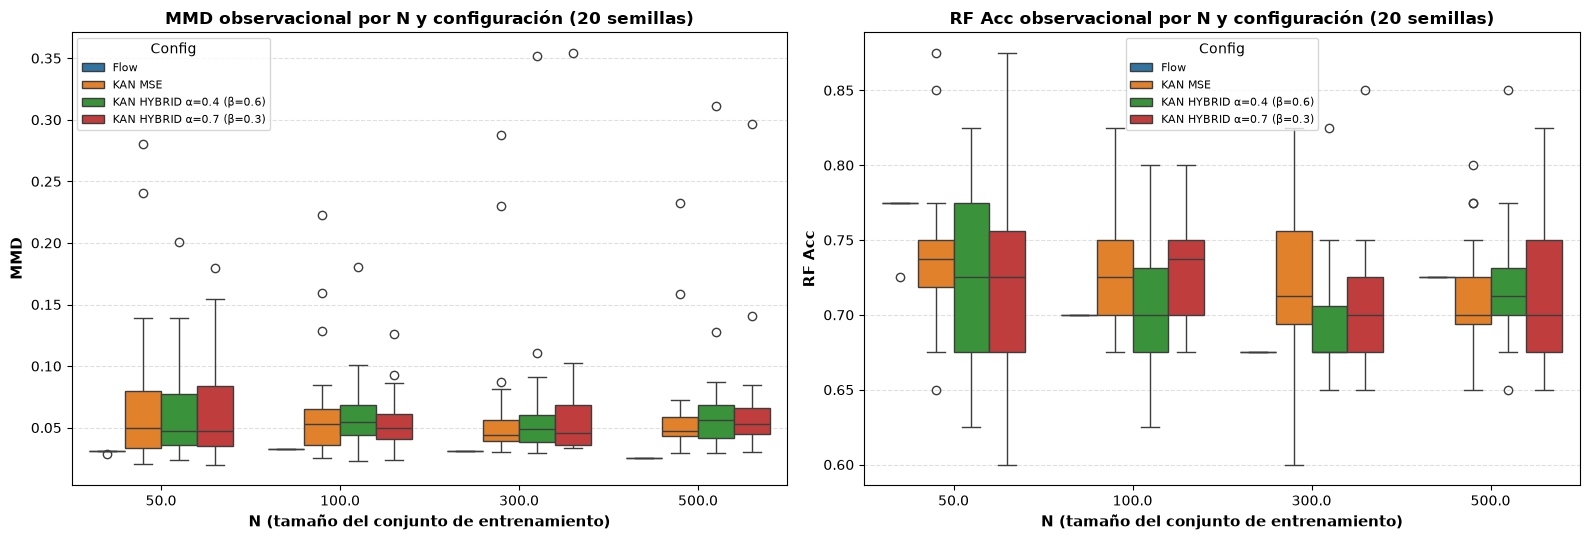

In [12]:
# ==============================================================================
# PASO 10: VISUALIZACIÓN - BOXPLOTS OBSERVACIONALES POR N Y CONFIGURACIÓN
# Un panel por métrica (MMD, RF Acc) | Eje X = N | Un color (hue) por Config
# Cada caja resume las semillas disponibles (mediana, RIC, outliers) -> mejor
# que media±std para ver si la varianza es simétrica o hay semillas concretas
# que se disparan (esto último se pierde en una banda ±std).
# ------------------------------------------------------------------------------
# Experimento puramente observacional: sin MMD/MAE interventional ni
# contrafactual (queda fuera de esta comparación a petición expresa).
# Se excluye "KAN HSIC" (β=1), igual que en el gráfico anterior.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

configs_kan_box = [
    ('mse', None, 'KAN MSE'),
    ('hybrid', 0.4, 'KAN HYBRID α=0.4 (β=0.6)'),
    ('hybrid', 0.7, 'KAN HYBRID α=0.7 (β=0.3)'),
]

registros_box = []

# Una fila por semilla para el Flow
for _, row in df_flow.iterrows():
    registros_box.append({'N': row['N'], 'Config': 'Flow', 'MMD': row['MMD'], 'RF Acc': row['RF Acc']})

# Una fila por semilla para cada config del KAN seleccionada
for loss_name, alpha_val, etiqueta in configs_kan_box:
    grp = df_final_multi_n[df_final_multi_n['Loss'] == loss_name]
    if alpha_val is not None:
        grp = grp[np.isclose(grp['Alpha'], alpha_val)]
    for _, row in grp.iterrows():
        registros_box.append({'N': row['N'], 'Config': etiqueta, 'MMD': row['MMD'], 'RF Acc': row['RF Acc']})

df_box = pd.DataFrame(registros_box)

n_semillas_usadas = df_box.groupby(['N', 'Config']).size().max()

metricas_box = ['MMD', 'RF Acc']
fig, axes = plt.subplots(1, len(metricas_box), figsize=(8 * len(metricas_box), 5.5))

for ax, metrica in zip(axes, metricas_box):
    sns.boxplot(data=df_box, x='N', y=metrica, hue='Config', ax=ax)
    ax.set_title(f'{metrica} observacional por N y configuración ({n_semillas_usadas} semillas)', fontsize=12, fontweight='bold')
    ax.set_xlabel('N (tamaño del conjunto de entrenamiento)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.legend(fontsize=8, loc='best', title='Config')

plt.tight_layout()

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot = os.path.join('plots', 'boxplot_flow_vs_kan_aditivo_gausian.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica guardada: {ruta_plot}")
plt.show()